# Stage 1 EDA: Preliminary PDF Audit

This notebook performs a high-level audit of the downloaded San Diego Municipal Code PDFs (Chapters 11-15). 
Goal: Identify layout complexity, OCR needs, and table density to select the best conversion strategy.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# Constants
DATA_DIR = Path("../data/raw")
CHAPTERS = ["chapter_11", "chapter_12", "chapter_13", "chapter_14", "chapter_15"]

print(f"Data Directory: {DATA_DIR.resolve()}")

Data Directory: /Users/Aresh/Desktop/AAI 590/sd-land-use-rag/data/raw


## 1. File Inventory and Size Analysis

In [2]:
file_data = []

for chapter in CHAPTERS:
    chapter_path = DATA_DIR / chapter
    files = list(chapter_path.glob("*.pdf"))
    for f in files:
        file_data.append({
            "chapter": chapter,
            "filename": f.name,
            "size_kb": f.stat().st_size / 1024,
            "path": str(f)
        })

df = pd.DataFrame(file_data)
print(f"Total PDFs found: {len(df)}")
df.groupby("chapter")["size_kb"].agg(["count", "mean", "max", "min"]).round(2)

Total PDFs found: 245


,count,mean,max,min
chapter,,,,
chapter_11,10,228.30,947.64,12.02
chapter_12,49,100.03,235.58,9.94
chapter_13,22,598.15,3601.23,9.58
chapter_14,108,160.85,935.57,16.17
chapter_15,56,202.00,3672.50,52.92


<Figure size 1000x600 with 0 Axes>

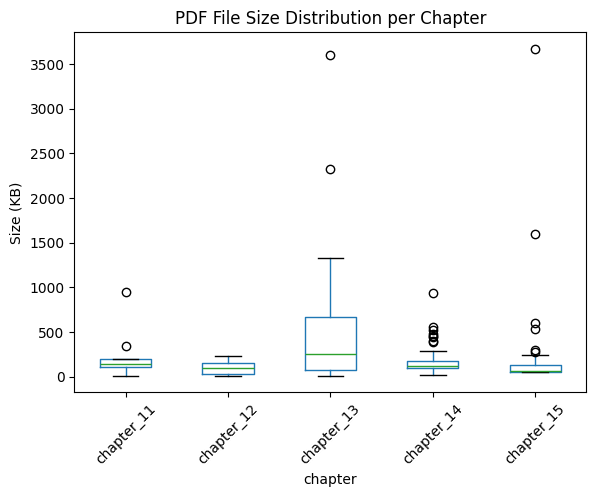

In [3]:
plt.figure(figsize=(10, 6))
df.boxplot(column='size_kb', by='chapter', grid=False, rot=45)
plt.title('PDF File Size Distribution per Chapter')
plt.ylabel('Size (KB)')
plt.suptitle('') # Remove automatic subtitle
plt.show()

## 2. Structural Inspection (Sampling)
We'll peek at the metadata and first few lines of text of the largest/smallest files to see if OCR is needed.

In [4]:
from unstructured.partition.pdf import partition_pdf
import warnings
warnings.filterwarnings('ignore')

def peek_pdf(file_path):
    print(f"\nInspecting: {Path(file_path).name}")
    try:
        # Use fast strategy to check if text is extractable directly
        elements = partition_pdf(filename=file_path, strategy="fast")
        text_content = "\n".join([str(e) for e in elements[:10]]) # First 10 elements
        print(f"Extracted text length (first 10 elements): {len(text_content)}")
        if len(text_content.strip()) < 50:
            print("WARNING: Very little text found. This file might be an image/scan requiring OCR.")
        else:
            print("Sample Content Preview:")
            print(text_content[:500] + "...")
    except Exception as e:
        print(f"Error partitioning file: {e}")

# Sample a few files (Largest, Median, Smallest)
samples = pd.concat([
    df.sort_values("size_kb").head(1),
    df.sort_values("size_kb").tail(1),
    df.sample(1)
])

for idx, row in samples.iterrows():
    peek_pdf(row['path'])

/Users/Aresh/Desktop/AAI 590/sd-land-use-rag/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/Aresh/Desktop/AAI 590/sd-land-use-rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Inspecting: Ch13Art02Division03.pdf
Extracted text length (first 10 elements): 256
Sample Content Preview:
San Diego Municipal Code (8-2022)
Article 2: Overlay Zones
Division 3: Airport Environs Overlay Zone (Added 12-9-1997 by O-18451 N.S.; effective 1-1-2000.) (Repealed 12-17-2021 by O-21380 N.S.; effective 1-16-2022.)
Chapter 13: Zones
Ch. Art. Div. 3 2 13
1...

Inspecting: Ch15Art06Division03.pdf
Extracted text length (first 10 elements): 418
Sample Content Preview:
San Diego Municipal Code (2-2025)
Chapter 15: Planned Districts
Article 6: Planned Districts (Added 4-3-2006 by O-19471 N.S.)
Division 3: The Centre City Planned District (Added 4-3-2006 by O-19471 N.S.)
§156.0301
Purpose and Applicability
(a)
Purpose
The purpose of the Centre City Planned District is to establish land use regulations and design and development criteria to implement the Downtown Community Plan.
(b)...

Inspecting: Ch15Art04Division04.pdf
Extracted text length (first 10 elements): 394
Sample Content Pre

## 3. Findings Summary
- **OCR Necessity**: None. All sampled PDFs contain native embedded text layers; the `fast` strategy extracted clean content successfully.
- **Layout Complexity**: Low-to-moderate. Consistent structure with clear section markers (§), chapter/article/division headers, and ordinance metadata.
- **Table Density**: Moderate. Regulatory tables are present but not dominant; layout-aware parsing may be needed for specific sections.
- **Recommended Tool**: `unstructured` (`partition_pdf`, `strategy='fast'`) for the bulk pipeline. Evaluate `marker-pdf` on table-heavy files in Stage 2.